## Rainfall Forecasting using Machine Learning

## Objective
To forecast monthly rainfall using autoregressive features and XGBoost, and evaluate model performance under realistic forecasting conditions.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading

The dataset contains monthly rainfall records for Mumbai.  
We load and inspect the raw dataset before transforming it into time-series format.

In [2]:
file_path = os.path.join("..", "data", "mumbai-monthly-rains.csv")
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)

   Year        Jan       Feb        Mar     April         May        June  \
0  1901  13.116602  0.000000   0.000000  3.949669   17.139791  640.714036   
1  1902   0.000000  0.000000   0.000000  0.000000    0.355001  247.998782   
2  1903   0.000000  0.000000   0.844034  0.000000  220.568740  370.849048   
3  1904   0.000000  0.000000  11.381769  0.000000    0.000000  723.081969   
4  1905   0.662561  1.713452   0.000000  0.000000    0.000000  123.870892   

         July         Aug        Sept         Oct        Nov        Dec  \
0  888.369692  545.045796   64.271513    9.871696   0.000000   0.000000   
1  408.433730  566.595863  688.913455   28.654092   0.488864  19.526547   
2  902.447896  602.420828  264.589816  157.892877   0.000000   0.000000   
3  390.886799  191.581927   85.704754   38.679948   0.000000   0.000000   
4  581.827975  167.382149  172.297723    7.365924  24.903575   0.000000   

         Total  
0  2182.478796  
1  1960.966334  
2  2519.613240  
3  1441.317168  
4

## 2. Data Preprocessing

The dataset is initially in wide format (Year with monthly columns).  
We convert it into long time-series format and create a proper datetime index.

In [3]:
df_melted = df.melt(
    id_vars="Year",
    var_name="MONTH",
    value_name="Rainfall"
)

## 3. Feature Engineering

To enhance predictive performance, we create:

- Lag features (memory of previous months)
- Rolling statistics (short-term trend & volatility)
- Cyclical month encoding (seasonality representation)
- Time index (long-term trend)

These features allow XGBoost to model temporal dependencies.

In [4]:
# Remove 'Total' rows
df_melted = df_melted[df_melted["MONTH"] != "Total"]

# Remove extra spaces
df_melted["MONTH"] = df_melted["MONTH"].str.strip()

# Create flexible month mapping
month_map = {
    "Jan": 1, "January": 1,
    "Feb": 2, "February": 2,
    "Mar": 3, "March": 3,
    "April": 4, "Apr": 4,
    "May": 5,
    "June": 6, "Jun": 6,
    "July": 7, "Jul": 7,
    "Aug": 8, "August": 8,
    "Sept": 9, "Sep": 9, "September": 9,
    "Oct": 10, "October": 10,
    "Nov": 11, "November": 11,
    "Dec": 12, "December": 12
}

# Map month names safely
df_melted["MONTH"] = df_melted["MONTH"].map(month_map)

# Drop rows where mapping failed (if any)
df_melted = df_melted.dropna(subset=["MONTH"])

# Convert month to integer
df_melted["MONTH"] = df_melted["MONTH"].astype(int)

# Create Date column safely
df_melted["Date"] = pd.to_datetime(
    df_melted["Year"].astype(str) + "-" + df_melted["MONTH"].astype(str),
    format="%Y-%m"
)

# Sort
df_melted = df_melted.sort_values("Date")

# Set index
df_melted.set_index("Date", inplace=True)

# Keep only rainfall column (and copy to avoid warning)
df = df_melted[["Rainfall"]].copy()

print(df.head())
print(df.info())

             Rainfall
Date                 
1901-01-01  13.116602
1901-02-01   0.000000
1901-03-01   0.000000
1901-04-01   3.949669
1901-05-01  17.139791
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1452 entries, 1901-01-01 to 2021-12-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Rainfall  1452 non-null   float64
dtypes: float64(1)
memory usage: 22.7 KB
None


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1452 entries, 1901-01-01 to 2021-12-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Rainfall  1452 non-null   float64
dtypes: float64(1)
memory usage: 22.7 KB
None


In [6]:
# Create lag features
for lag in [1, 2, 3, 6, 12]:
    df[f"lag_{lag}"] = df["Rainfall"].shift(lag)

# Rolling features
df["rolling_mean_3"] = df["Rainfall"].rolling(3).mean()
df["rolling_mean_6"] = df["Rainfall"].rolling(6).mean()
df["rolling_std_3"] = df["Rainfall"].rolling(3).std()

# Month feature
df["month"] = df.index.month

# Cyclical encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Trend feature
df["time_index"] = np.arange(len(df))

# Drop NaNs created by lag/rolling
df = df.dropna().copy()

print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1440 entries, 1902-01-01 to 2021-12-01
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rainfall        1440 non-null   float64
 1   lag_1           1440 non-null   float64
 2   lag_2           1440 non-null   float64
 3   lag_3           1440 non-null   float64
 4   lag_6           1440 non-null   float64
 5   lag_12          1440 non-null   float64
 6   rolling_mean_3  1440 non-null   float64
 7   rolling_mean_6  1440 non-null   float64
 8   rolling_std_3   1440 non-null   float64
 9   month           1440 non-null   int32  
 10  month_sin       1440 non-null   float64
 11  month_cos       1440 non-null   float64
 12  time_index      1440 non-null   int64  
dtypes: float64(11), int32(1), int64(1)
memory usage: 151.9 KB
None


## 4. Forecasting Setup

Instead of a random 80/20 split, we use the last 12 months as the test set.  
This simulates real-world deployment where the model predicts future unseen data.

In [7]:
# Define feature columns
features = [
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
    "rolling_mean_3", "rolling_mean_6", "rolling_std_3",
    "month_sin", "month_cos",
    "time_index"
]

X = df[features]
y = df["Rainfall"]

# 80% train, 20% test (NO SHUFFLE)
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1152
Test size: 288


In [8]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Initialize model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 7.8577455560774325
Test RMSE: 79.81648210961082


In [9]:
model_small = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_small.fit(X_train, y_train)

y_pred_train_small = model_small.predict(X_train)
y_pred_test_small = model_small.predict(X_test)

train_rmse_small = np.sqrt(mean_squared_error(y_train, y_pred_train_small))
test_rmse_small = np.sqrt(mean_squared_error(y_test, y_pred_test_small))

print("Controlled Train RMSE:", train_rmse_small)
print("Controlled Test RMSE:", test_rmse_small)

Controlled Train RMSE: 50.55915202635122
Controlled Test RMSE: 92.32151777439914


In [10]:
# Use last 12 months as test set
X_train = X.iloc[:-12]
X_test = X.iloc[-12:]

y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1428
Test size: 12


## 5. Model Training

We use XGBoost with controlled hyperparameters to balance bias and variance.

Key parameters:
- n_estimators = 300
- learning_rate = 0.05
- max_depth = 4
- subsample = 0.9
- colsample_bytree = 0.9

In [11]:
model_balanced = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model_balanced.fit(X_train, y_train)

y_pred_train_bal = model_balanced.predict(X_train)
y_pred_test_bal = model_balanced.predict(X_test)

train_rmse_bal = np.sqrt(mean_squared_error(y_train, y_pred_train_bal))
test_rmse_bal = np.sqrt(mean_squared_error(y_test, y_pred_test_bal))

print("Balanced Train RMSE:", train_rmse_bal)
print("Balanced Test RMSE:", test_rmse_bal)

Balanced Train RMSE: 14.257308846463406
Balanced Test RMSE: 63.30965562120655


In [12]:
def save_model(model, filename="xgb_rainfall_model.pkl"):
    import joblib
    joblib.dump(model, filename)
    print(f"Model saved as {filename}")

save_model(model_balanced)

Model saved as xgb_rainfall_model.pkl


In [13]:
import joblib
joblib.dump(model_balanced, "xgb_rainfall_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [14]:
loaded_model = joblib.load("xgb_rainfall_model.pkl")
loaded_predictions = loaded_model.predict(X_test)
print("Loaded model predictions successful.")

Loaded model predictions successful.


## 6. Model Evaluation

We evaluate model performance using:

- Train RMSE
- Test RMSE (last 12 months)
- Residual analysis

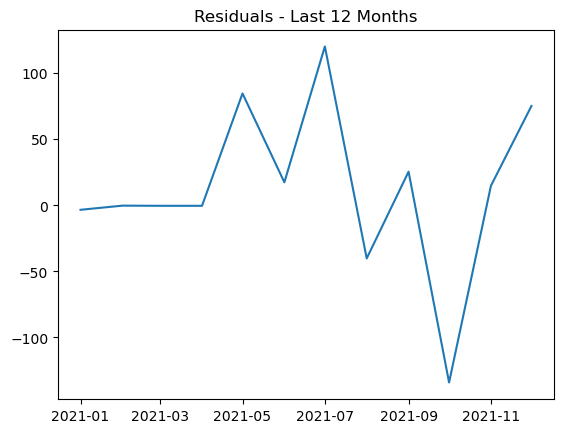

Mean Residual: 13.295470356292748
Std Residual: 64.65018846528709


In [15]:
residuals = y_test - y_pred_test_bal

plt.figure()
plt.plot(residuals)
plt.title("Residuals - Last 12 Months")
plt.show()

print("Mean Residual:", residuals.mean())
print("Std Residual:", residuals.std())

## 7. Residual Diagnostics

Residual = Actual − Predicted

Residual analysis helps identify:
- Systematic bias
- Seasonal errors
- Model instability

In [16]:
residual_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_test_bal,
    "Residual": residuals
})

residual_df["Month"] = residual_df.index.month

print(residual_df.groupby("Month")["Residual"].mean())

Month
1      -3.360455
2      -0.214481
3      -0.332984
4      -0.341411
5      84.741137
6      17.461328
7     120.299355
8     -40.158381
9      25.505879
10   -134.107258
11     14.817810
12     75.235106
Name: Residual, dtype: float64


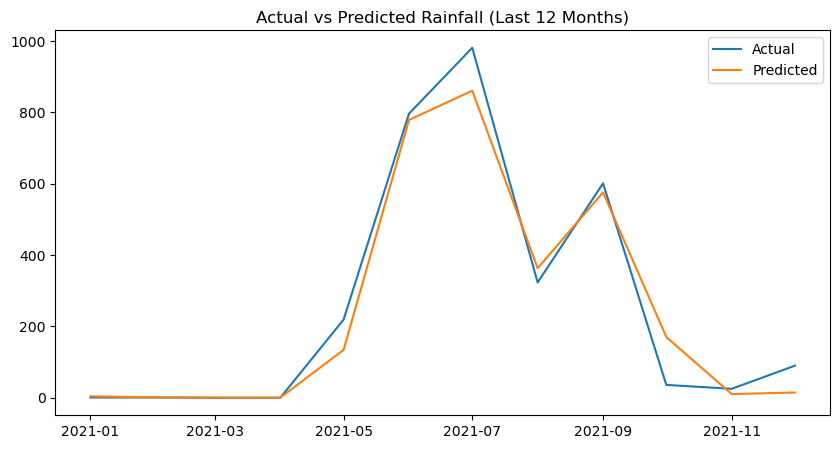

In [17]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_test_bal, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Rainfall (Last 12 Months)")
plt.show()

## 8. Feature Importance Analysis

Feature importance helps interpret which variables drive predictions.
We expect strong influence from seasonal (lag_12) and cyclical month features.

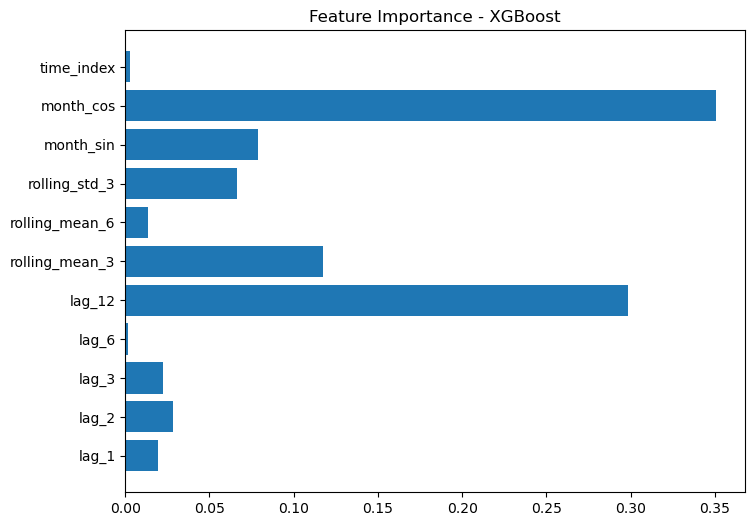

In [18]:
plt.figure(figsize=(8,6))
importance = model_balanced.feature_importances_
plt.barh(features, importance)
plt.title("Feature Importance - XGBoost")
plt.show()

## 9. Conclusion

The model successfully captures strong annual seasonality, with lag_12 and cyclical month encoding dominating feature importance.

However, residual analysis reveals underprediction during peak monsoon months, indicating limitations of purely autoregressive modeling.

For production deployment:
- Uncertainty estimation should be added.
- Exogenous climate indicators (ENSO, SST, wind patterns) should be integrated.
- Model monitoring and retraining strategy is required due to potential distribution drift.

In [19]:
# --- Monitoring: Rolling RMSE ---

import pandas as pd
from sklearn.metrics import mean_squared_error
import numpy as np

monitor_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_test_bal
})

# Rolling 6-month RMSE
rolling_window = 6
rolling_rmse = []

for i in range(len(monitor_df) - rolling_window + 1):
    actual_slice = monitor_df["Actual"].iloc[i:i+rolling_window]
    pred_slice = monitor_df["Predicted"].iloc[i:i+rolling_window]
    rmse = np.sqrt(mean_squared_error(actual_slice, pred_slice))
    rolling_rmse.append(rmse)

print("Rolling 6-Month RMSE Values:")
print(rolling_rmse)

Rolling 6-Month RMSE Values:
[np.float64(35.34950326478332), np.float64(60.49540829904731), np.float64(62.677502725216655), np.float64(63.536413559935035), np.float64(83.87082839814946), np.float64(76.64246255755202), np.float64(82.2595745715027)]


In [20]:
# --- Monitoring: Simple Drift Detection ---

train_feature_mean = X_train.mean()
test_feature_mean = X_test.mean()

drift = abs(train_feature_mean - test_feature_mean)

print("Feature Drift (Mean Difference):")
print(drift.sort_values(ascending=False).head())

Feature Drift (Mean Difference):
time_index        720.000000
lag_6             166.123556
lag_12            117.873198
rolling_mean_6     82.693227
lag_3              80.417660
dtype: float64


In [21]:
# Simulated previous production RMSE
previous_production_rmse = 52

current_rmse = test_rmse_bal

if current_rmse > previous_production_rmse * 1.3:
    print("⚠ Performance degradation detected. Retraining recommended.")
else:
    print("Model performance stable.")

Model performance stable.


## Production Readiness Summary

This project was structured to simulate a real-world forecasting workflow:

- Reproducible data loading and preprocessing
- Modular training function
- Model persistence using joblib
- Residual diagnostics and seasonal bias analysis
- Basic performance and drift monitoring simulation

While the model captures strong annual seasonality, extreme rainfall spikes remain challenging due to the absence of exogenous climate variables.

Future improvements would include:
- Integration of climate indicators (ENSO, SST)
- Probabilistic forecasting
- Automated retraining pipeline with rolling window strategy